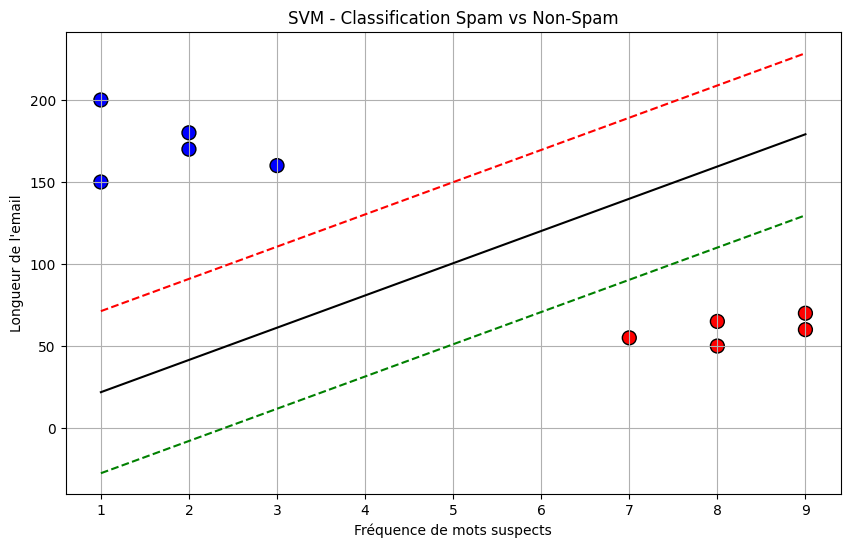

In [ ]:
#svm
import numpy as np
import matplotlib.pyplot as plt

# ================================================================
# 1. PRÉPARATION DES DONNÉES
# ================================================================
# Problème de classification binaire :
# On veut prédire si un email est SPAM (+1) ou NON SPAM (-1)
#
# Chaque email est représenté par 2 features :
# X[:,0] = fréquence de mots suspects (ex: "win", "free")
# X[:,1] = longueur de l'email

X = np.array([
    [1, 200], [2, 180], [1, 150], [2, 170], [3, 160],   # Non spam (-1)
    [8, 50], [9, 60], [7, 55], [8, 65], [9, 70]         # Spam (+1)
])

# Labels :
# -1 → Non spam
# +1 → Spam
# En SVM, on utilise {-1, +1} car la décision dépend du signe
y = np.array([-1, -1, -1, -1, -1, 1, 1, 1, 1, 1])


# ================================================================
# 2. MODÈLE SVM
# ================================================================
class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        # learning_rate : contrôle la taille des mises à jour des paramètres
        self.lr = learning_rate

        # lambda_param : terme de régularisation
        # Permet d'éviter le surapprentissage en contrôlant la complexité du modèle
        self.lambda_param = lambda_param

        # nombre d'itérations d'entraînement
        self.n_iters = n_iters

        # paramètres du modèle
        self.w = None  # poids
        self.b = None  # biais

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialisation des paramètres
        # On commence avec des valeurs nulles
        self.w = np.zeros(n_features)
        self.b = 0

        # Boucle d'apprentissage
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):

                # --------------------------------------------------
                # Fonction de décision du SVM :
                # y_i * (w.x_i - b)
                #
                # Si >= 1 → bonne classification avec marge suffisante
                # Si < 1  → erreur ou point dans la marge
                # --------------------------------------------------
                condition = y[idx] * (np.dot(x_i, self.w) - self.b) >= 1

                if condition:
                    # Cas où l'exemple est correctement classé
                    # On applique seulement la régularisation
                    # Objectif : maximiser la marge
                    self.w -= self.lr * (2 * self.lambda_param * self.w)

                else:
                    # Cas où l'exemple est mal classé ou dans la marge
                    # On corrige la classification + régularisation
                    self.w -= self.lr * (
                        2 * self.lambda_param * self.w - np.dot(x_i, y[idx])
                    )

                    # Ajustement du biais pour améliorer la séparation
                    self.b -= self.lr * y[idx]

    def predict(self, X):
        # Calcul du score de décision
        linear_output = np.dot(X, self.w) - self.b

        # Conversion en classe via le signe
        return np.sign(linear_output)


# ================================================================
# 3. ENTRAINEMENT DU MODÈLE
# ================================================================
model = SVM()
model.fit(X, y)


# ================================================================
# 4. VISUALISATION DU MODÈLE
# ================================================================
def visualize_svm():

    def get_hyperplane_value(x, w, b, v):
        # Permet de tracer les droites définies par :
        # w.x - b = v
        #
        # v = 0  → frontière de décision
        # v = ±1 → marges du SVM
        return (-w[0] * x + b + v) / w[1]

    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(1,1,1)

    # Affichage des exemples
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=100, edgecolors='k')

    x0_1 = np.amin(X[:,0])
    x0_2 = np.amax(X[:,0])

    # Frontière de décision
    y_1 = get_hyperplane_value(x0_1, model.w, model.b, 0)
    y_2 = get_hyperplane_value(x0_2, model.w, model.b, 0)
    ax.plot([x0_1, x0_2], [y_1, y_2], 'k')

    # Marges
    y_m1 = get_hyperplane_value(x0_1, model.w, model.b, 1)
    y_m2 = get_hyperplane_value(x0_2, model.w, model.b, 1)
    ax.plot([x0_1, x0_2], [y_m1, y_m2], 'g--')

    y_m3 = get_hyperplane_value(x0_1, model.w, model.b, -1)
    y_m4 = get_hyperplane_value(x0_2, model.w, model.b, -1)
    ax.plot([x0_1, x0_2], [y_m3, y_m4], 'r--')

    plt.title("SVM - Classification Spam vs Non-Spam")
    plt.xlabel("Fréquence de mots suspects")
    plt.ylabel("Longueur de l'email")
    plt.grid()
    plt.show()


visualize_svm()

Résultat : Bénigne


IndexError: index 1 is out of bounds for axis 0 with size 1

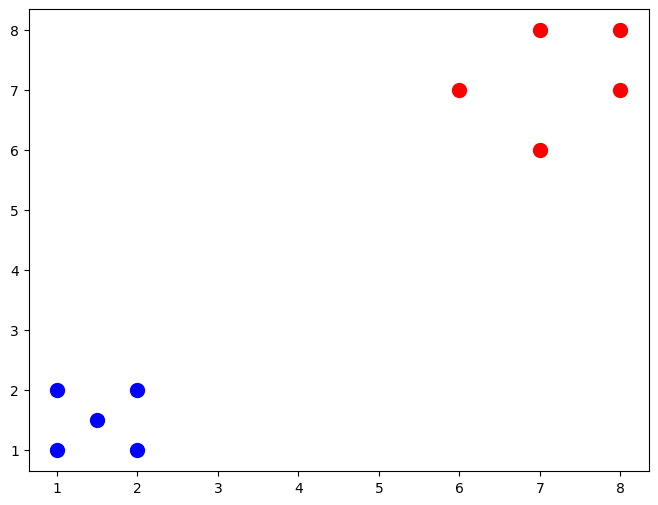

In [1]:
#knn
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# =================================================================
# 1. PRÉPARATION DES DONNÉES
# =================================================================
# Problème : classification d'une tumeur
#
# Classe 0 → tumeur bénigne
# Classe 1 → tumeur maligne
#
# Features :
# X[:,0] = taille de la tumeur
# X[:,1] = texture (irrégularité)

X_train = np.array([
    [1, 1], [2, 1], [1, 2], [2, 2], [1.5, 1.5],   # bénigne
    [6, 7], [7, 8], [8, 7], [7, 6], [8, 8]        # maligne
])

y_train = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])


# =================================================================
# 2. FONCTION DE DISTANCE
# =================================================================
def euclidean_distance(x1, x2):
    # Mesure de similarité entre deux observations
    # Distance petite → observations similaires
    return np.sqrt(np.sum((x1 - x2) ** 2))


# =================================================================
# 3. IMPLEMENTATION DU KNN
# =================================================================
class KNN:
    def __init__(self, k=3):
        # Nombre de voisins utilisés pour la décision
        self.k = k

    def fit(self, X, y):
        # Stockage des données d'entraînement
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        # Prédiction pour plusieurs exemples
        return [self._predict(x) for x in X]

    def _predict(self, x):
        # --------------------------------------------------
        # 1. Calcul des distances
        # --------------------------------------------------
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]

        # --------------------------------------------------
        # 2. Sélection des k voisins les plus proches
        # --------------------------------------------------
        k_indices = np.argsort(distances)[:self.k]
        self.k_indices = k_indices  # utilisé pour la visualisation

        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # --------------------------------------------------
        # 3. Vote majoritaire
        # --------------------------------------------------
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]


# =================================================================
# 4. TEST DU MODÈLE
# =================================================================
model = KNN(k=3)
model.fit(X_train, y_train)

# Nouvelle tumeur à classifier
X_new = np.array([[3, 3]])

prediction = model.predict(X_new)

# Conversion en texte pour affichage
label = "Maligne" if prediction[0] == 1 else "Bénigne"

print("Résultat :", label)


# =================================================================
# 5. VISUALISATION DES VOISINS
# =================================================================
plt.figure(figsize=(8, 6))

# Affichage des classes connues
plt.scatter(
    X_train[y_train==0, 0],
    X_train[y_train==0, 1],
    color='blue',
    s=100,
    label='Tumeur bénigne (Classe 0)'
)

plt.scatter(
    X_train[y_train==1, 0],
    X_train[y_train==1, 1],
    color='red',
    s=100,
    label='Tumeur maligne (Classe 1)'
)

# Affichage du point à prédire
plt.scatter(
    X_new[0],
    X_new[1],
    color='green',
    marker='*',
    s=300,
    label='Nouvelle tumeur'
)

# --------------------------------------------------
# Mise en évidence des K voisins
# --------------------------------------------------
neighbors = model.k_indices

for i in neighbors:
    plt.scatter(
        X_train[i][0],
        X_train[i][1],
        facecolors='none',
        edgecolors='black',
        s=200,
        linewidths=2
    )

    # Lignes vers les voisins
    plt.plot(
        [X_new[0][0], X_train[i][0]],
        [X_new[0][1], X_train[i][1]],
        linestyle='--'
    )

# Mise en forme
plt.title(f'KNN From Scratch (K=3) - Résultat : {label}')
plt.xlabel('Taille de la tumeur')
plt.ylabel('Texture')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()